# 37 — Model expansion as an action (nb36's showcase + the new hub + the wake/reduce/sample ledger)

**Why this notebook exists.** nb36 rendered the structural paradigm shift in the paper's five
figures. nb37 keeps that exact showcase on the same principled phlogiston relational model and
adds the piece §3.2 names but never writes down: the **decision** to revise *structure*. The
agent prices three moves on one ledger and chooses among them:

| move | what it chooses | scored by | cost |
|---|---|---|---|
| **sample** | keep the structure, just infer | — | — |
| **reduce** | prune an edge the data drop | closed-form ΔF (Savage–Dickey) | cheap, no new inversion |
| **expand** | *wake a dormant hub* — propose a new common cause | model Bayes factor + epistemic gain | the one real inversion |

This is the paper's "exploration **is** expansion, no bonus added" (Friston et al. 2023,
*Supervised structure learning*: every structural move scored by `ΔF + ΔG`). The proposal is
**Eq. (2) read backwards**: marginalizing a hidden hub induces a coupling among its neighbours
where the joint had a zero, so an *un*explained partial correlation is the fingerprint of a hub
not yet drawn. `action.propose_hub` eigendecomposes that residual block — leading eigenvalue =
the floor height (the trigger), leading eigenvector = the hub's coupling pattern.

**The honest dual finding (reported, not hidden).** On the relational substrate the paradigm can
hold a residual coupling *directly* in its precision, so the model evidence **declines** a hub
(`ΔF < 0` — normal science; structure learnable without expansion). Expansion strictly **wins**
only for an *unconceived* dimension: a residual on commitments the paradigm holds conditionally
independent, which no rewiring within the support can reach. That is the black hole, and waking a
hub is the escape — unless conviction vetoes it.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax, jax.numpy as jnp
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, shells, plot, observables as obs
from src.structural import bmr, phlogiston as ph, action
from src.structural.agent import evidence_race
from src.structural.belief import GaussianBeliefNet

RESULTS = pathlib.Path(ROOT if (ROOT / 'results').exists() else ROOT.parent) / 'results' / 'structural_model_expansion'
RESULTS.mkdir(parents=True, exist_ok=True)
KEY = jax.random.PRNGKey(0)

# the same headline scenario as nb36: relational substrate, world flips phlogiston->oxygen at t=40
cfg = StructuralConfig(n_agents=120, n_steps=120, t_shift=40, observation_operator='relational',
                       precision_mode='derived', core_governance=0.0)
print('scenario:', cfg.observation_operator, 'substrate · regime shift at t =', cfg.t_shift)

scenario: relational substrate · regime shift at t = 40


# Part A — nb36's five figures (the incumbent showcase, unchanged engine)

Exactly the views of nb36, so the expansion layer in Part B is added *to a known picture*.

## A1 — Log-evidence race across the fixed menu

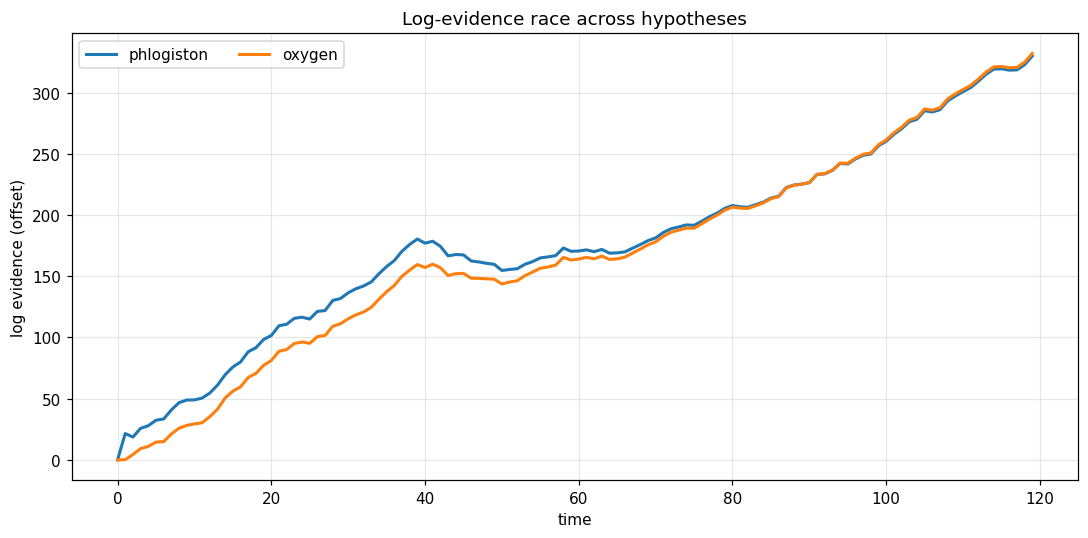

oxygen takes the lead for good at step 72 (shift at 40 )


In [2]:
race = evidence_race(cfg, KEY)
logZ = np.stack([np.asarray(race['logZ_phlog']), np.asarray(race['logZ_oxy'])], axis=1)
plot.plot_log_evidence_race(logZ, hypothesis_names=['phlogiston', 'oxygen'],
                            save_path=RESULTS / 'A1_log_evidence_race.png'); plt.show()
gap = logZ[:, 1] - logZ[:, 0]
post = np.arange(cfg.t_shift, cfg.n_steps); lead = post[gap[post] > 0]
print('oxygen takes the lead for good at step', int(lead[0]) if lead.size else -1, '(shift at', cfg.t_shift, ')')

## A2 — Mean-field hypothesis share

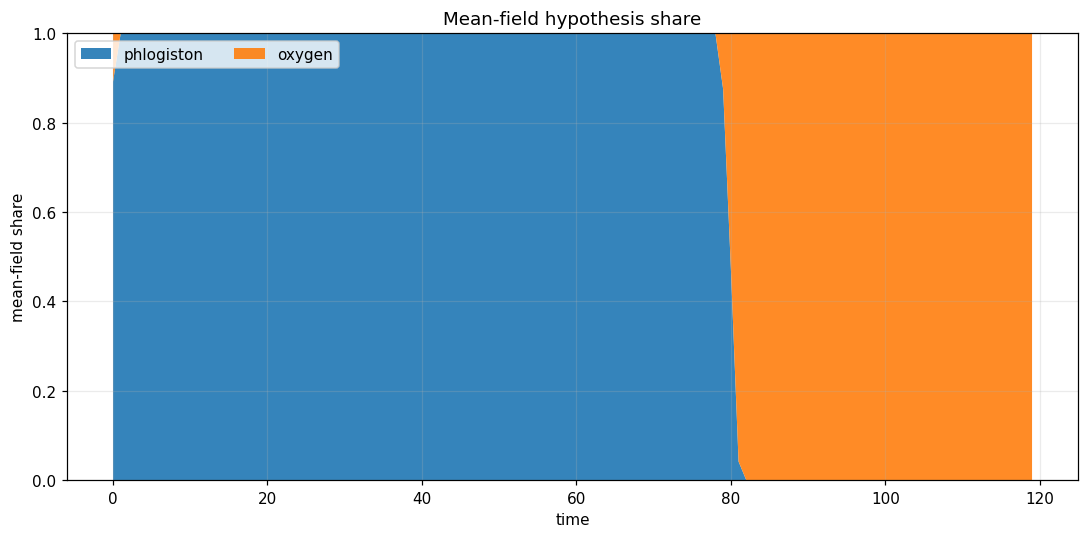

final oxygen share = 1.0


In [3]:
state = S.init_state(cfg, KEY)
idx_t = np.asarray(S.run_trace_index(cfg, state))
winner_tn = (idx_t > 0.5).astype(int)
plot.plot_mean_field_hypothesis_share(winner_tn=winner_tn, hypothesis_names=['phlogiston', 'oxygen'],
                                      save_path=RESULTS / 'A2_mean_field_share.png'); plt.show()
print('final oxygen share =', round(float(winner_tn[-1].mean()), 2))

## A3 — The paradigm as an evolving network (Bayes-net snapshots)

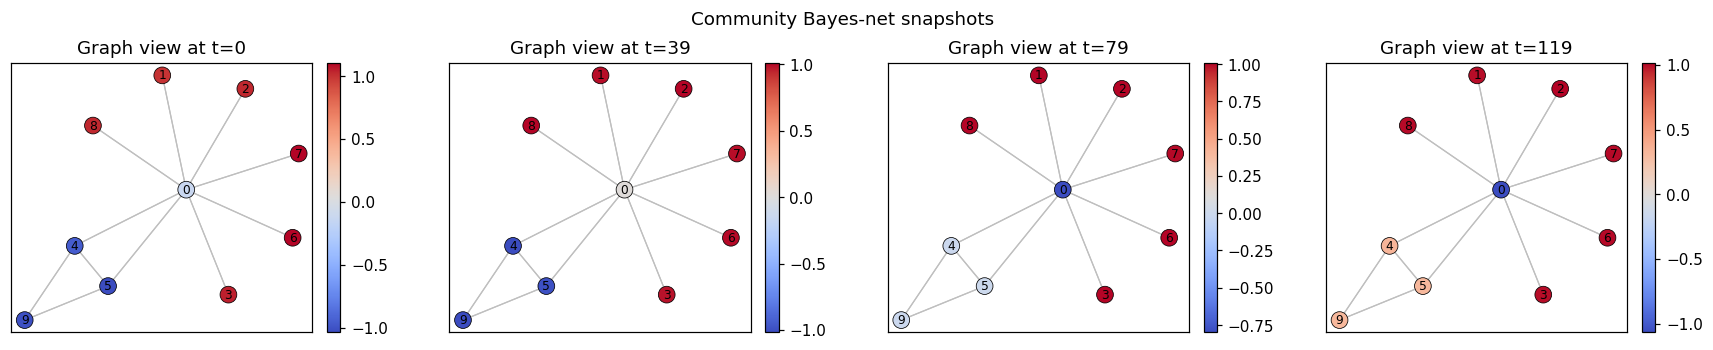

In [4]:
Pi_t, h_t = S.run_trace_net(cfg, state)
mu_t = np.stack([np.asarray(obs.population_means(Pi_t[t], h_t[t])) for t in range(cfg.n_steps)])
plot.plot_community_bayesnet_snapshots(np.asarray(Pi_t), mu_t, graph_only=True, max_snapshots=4,
        edge_threshold=0.15, layout_seed=3, save_path=RESULTS / 'A3_bayesnet_snapshots.png'); plt.show()

## A4 — Edge-edit timeline (expansion and reduction, read off the trajectory)

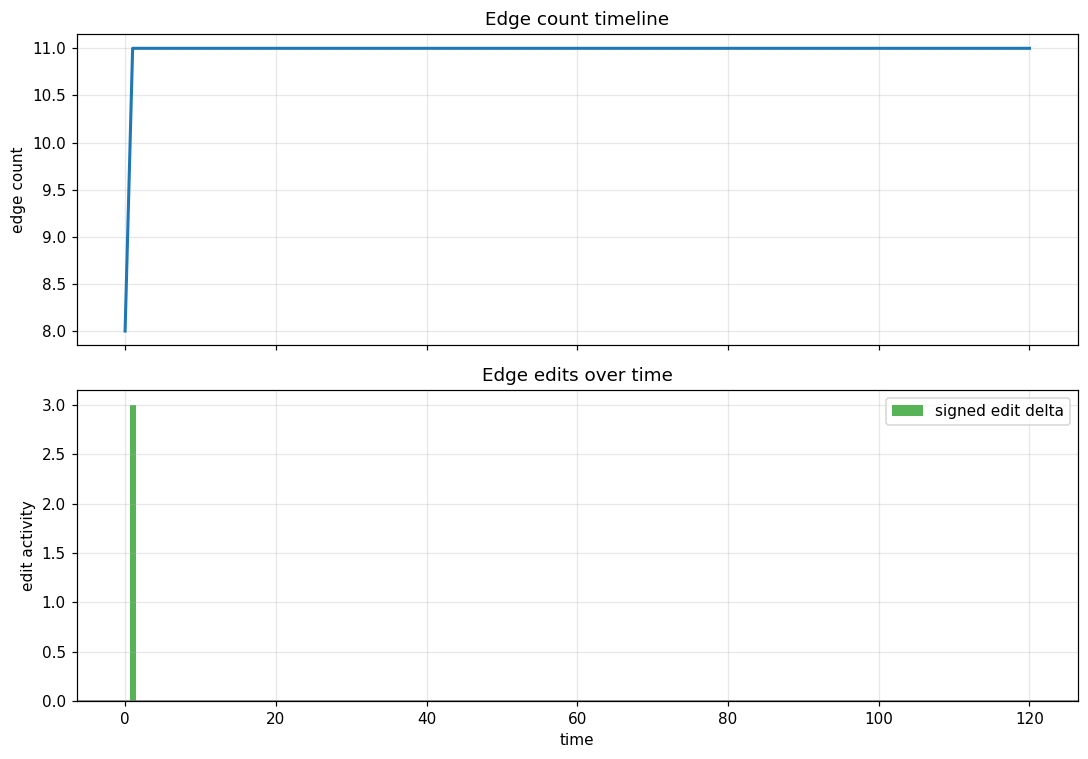

edge count: 8 (prior) -> 11 (learned)


In [5]:
counts, delta = shells.edge_count_trace(np.asarray(Pi_t), threshold=0.15)
d = len(cfg.node_names)
prior_Pi = np.abs(np.asarray(ph.phlogiston_prior(cfg).Pi))
prior_count = float((prior_Pi[np.triu_indices(d, 1)] > 0.15).sum())
counts = np.concatenate([[prior_count], counts]); delta = np.concatenate([[0.0], np.diff(counts)])
plot.plot_edge_edit_timeline(edge_count_t=counts, edge_edit_delta_t=delta,
                             save_path=RESULTS / 'A4_edge_edit_timeline.png'); plt.show()
print(f'edge count: {prior_count:.0f} (prior) -> {counts[-1]:.0f} (learned)')

## A5 — Community-distance heatmap (locked, isolated communities)

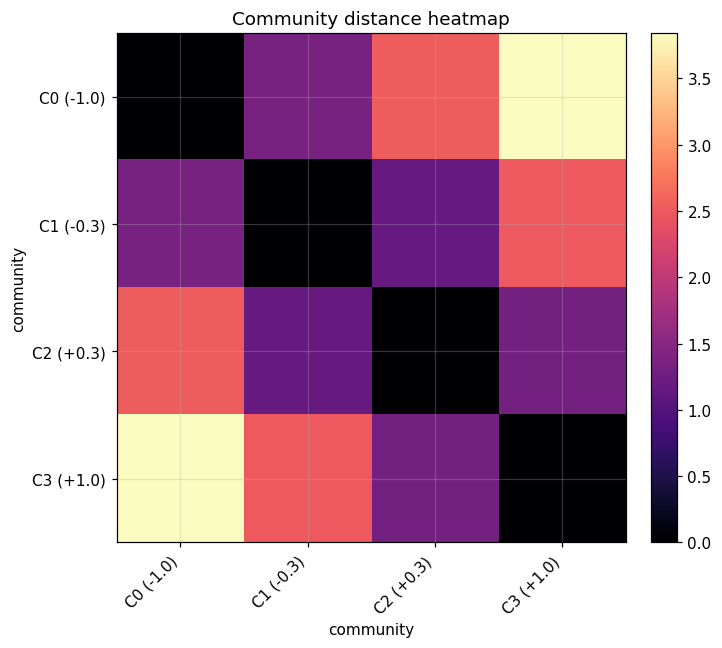

In [6]:
cfg_c = dataclasses.replace(cfg, n_agents=120, core_governance=400.0)
from src.structural import graphs as G
graph_c = G.community([30, 30, 30, 30], intra=0.3, inter=0.0)
sizes = [30, 30, 30, 30]; stances = [-1.0, -0.3, 0.3, 1.0]
groups = [{"count": s, "paradigm": "phlogiston", "stance": st} for s, st in zip(sizes, stances)]
st_c = S.init_state(cfg_c, KEY, groups=groups, W_override=graph_c.trust_W())
Pi_c, h_c = S.run_trace_net(cfg_c, st_c)
mu_fin = np.asarray(obs.population_means(Pi_c[-1], h_c[-1])); bounds = np.cumsum([0] + sizes)
comm_mu = np.stack([mu_fin[bounds[k]:bounds[k+1]].mean(0) for k in range(4)])
D = np.linalg.norm(comm_mu[:, None, :] - comm_mu[None, :, :], axis=2)
plot.plot_community_distance_heatmap(D, community_labels=[f'C{k} ({s:+.1f})' for k, s in enumerate(stances)],
                                     save_path=RESULTS / 'A5_community_distance_heatmap.png'); plt.show()

# Part B — the new model and the model expansion

We add a **dormant reservoir hub** to the paradigm and turn the three moves into a scored
decision. The reservoir node is inert until the data wire it in (the reserved-slot mechanism of
`test_structure_learning.py`); waking it is the expansion action.

## B1 — The genuine black hole: an *unconceived* dimension

The phlogiston paradigm holds the commitments `reduction_with_charcoal`,
`respiration_like_combustion`, `air_has_capacity` **conditionally independent** (each couples only
to the hidden hub, never to each other — verify below). We bury a hidden common cause among
exactly these three: a latent the paradigm does not represent, whose signature is a correlation no
edge *within the menu* can hold. This is Stanford's unconceived alternative — the residual that
needs **expansion**, not reduction or a paradigm switch.

In [7]:
prior = ph.phlogiston_prior(cfg)
names = cfg.node_names
buried = ('reduction_with_charcoal', 'respiration_like_combustion', 'air_has_capacity')
bi = [names.index(n) for n in buried]
print('buried nodes:', buried)
print('prior coupling AMONG them:', [round(float(prior.Pi[bi[i], bi[j]]), 3)
                                     for i in range(3) for j in range(3) if i < j],
      '<- the paradigm holds them conditionally independent')

def plant_common_cause(prior, bi, g=1.2, mu_z=2.0, reps=3):
    # Deposit reps observations generated by a hidden common cause z driving the buried
    # nodes (SEM x = A x + e); returns the posterior net the paradigm must now explain.
    A = np.zeros((4, 4)); A[0, 3] = A[1, 3] = A[2, 3] = g; I = np.eye(4)
    Pi4 = (I - A).T @ I @ (I - A); mu = np.array([g*mu_z, g*mu_z, g*mu_z, mu_z])
    sub = bmr.schur_marginalize(GaussianBeliefNet(Pi=jnp.asarray(Pi4), h=jnp.asarray(Pi4 @ mu),
                                                  names=('a', 'b', 'c', 'z')), ('z',))
    Jblk = (np.asarray(sub.Pi) - np.diag(np.diag(np.asarray(sub.Pi)))) * reps
    jblk = np.asarray(sub.h) * reps
    Pi = np.array(prior.Pi); h = np.array(prior.h)
    for i in range(3):
        h[bi[i]] += jblk[i]
        for j in range(3): Pi[bi[i], bi[j]] += Jblk[i, j]
    return GaussianBeliefNet(Pi=jnp.asarray(Pi), h=jnp.asarray(h), names=names)

post = plant_common_cause(prior, bi, g=1.2)
prop = action.propose_hub(post, buried)
print(f'\nresidual floor (trigger) lambda_max = {prop.strength:.3f},  rank-1 ratio = {prop.rank1_ratio:.2f}')
print('proposed hub coupling pattern:', dict(zip(buried, np.round(np.asarray(prop.pattern), 2))),
      '<- same-sign => a single common cause (Eq. 2 backwards)')

buried nodes: ('reduction_with_charcoal', 'respiration_like_combustion', 'air_has_capacity')
prior coupling AMONG them: [0.0, 0.0, 0.0] <- the paradigm holds them conditionally independent



residual floor (trigger) lambda_max = 1.624,  rank-1 ratio = 0.50
proposed hub coupling pattern: {'reduction_with_charcoal': np.float32(-0.58), 'respiration_like_combustion': np.float32(-0.58), 'air_has_capacity': np.float32(-0.58)} <- same-sign => a single common cause (Eq. 2 backwards)


## B2 — The three moves, scored on one ledger

Sample (do nothing, score 0), reduce (prune an existing edge — closed-form), expand (wake the
proposed hub — the inverse-Schur common cause). `select_action` takes the arg-max.

In [8]:
expand = action.expansion_score(post, prior, prop, 'buried_hub')
# a reducible edge the data still hold (a hub neighbour) -- closed-form BMR
reduce = action.reduction_score(post, prior, ('phlogiston', 'combustion_releases'))
print(f'EXPAND : delta_F={expand.delta_F:+7.2f}  delta_G={expand.delta_G:+5.2f}  score={expand.score:+7.2f}  accept={expand.accept}')
print(f'REDUCE : delta_F={reduce.delta_F:+7.2f}  (prune phlogiston-combustion edge)            accept={reduce.accept}')
print(f'SAMPLE : score=0 (the do-nothing baseline)')
chosen = action.select_action(post, prior, buried, 'buried_hub',
                              prune_edges=(('phlogiston', 'combustion_releases'),))
print('\n=> select_action chooses:', chosen['action'].upper())

EXPAND : delta_F= +22.44  delta_G=+2.29  score= +24.72  accept=True
REDUCE : delta_F=  -5.25  (prune phlogiston-combustion edge)            accept=False
SAMPLE : score=0 (the do-nothing baseline)

=> select_action chooses: EXPAND


## B3 — The wake materializes the new node (the paradigm grows)

The woken hub borders the net: a new row/column appears, coupling the three buried commitments
through a common cause. Left: the paradigm's precision before; right: after the wake.

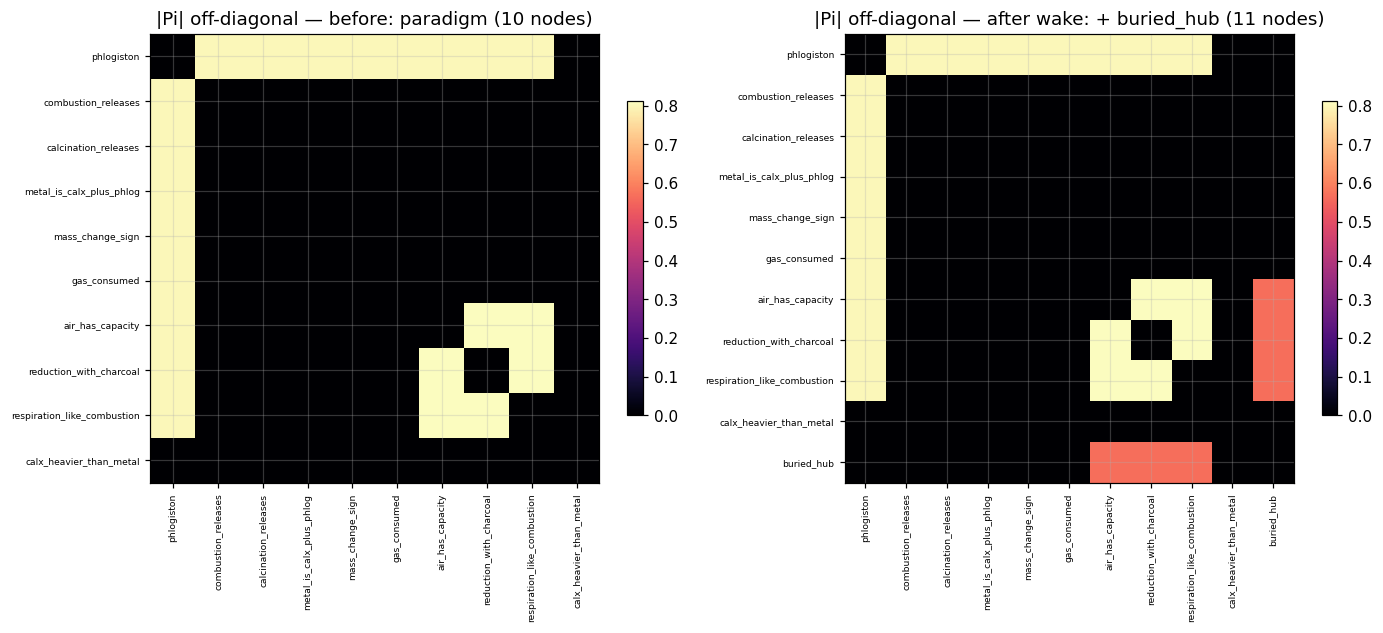

woken net dim: 11 (the new common-cause node is node 10 )


In [9]:
woken = action.wake_hub(post, prop, 'buried_hub', hub_self_prec=2.0)
fig, axs = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, net, ttl in [(axs[0], post, 'before: paradigm (10 nodes)'),
                     (axs[1], woken, 'after wake: + buried_hub (11 nodes)')]:
    P = np.abs(np.asarray(net.Pi)).copy(); np.fill_diagonal(P, 0.0)
    im = ax.imshow(P, cmap='magma'); ax.set_title(f'|Pi| off-diagonal — {ttl}')
    labs = list(net.names)
    ax.set_xticks(range(len(labs))); ax.set_yticks(range(len(labs)))
    ax.set_xticklabels(labs, rotation=90, fontsize=6); ax.set_yticklabels(labs, fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.savefig(RESULTS / 'B3_wake_materializes_node.png'); plt.show()
print('woken net dim:', woken.dim, '(the new common-cause node is node', woken.dim - 1, ')')

## B4 — The expansion is *declined* when the structure is directly learnable

The honest contrast. On the **relational** substrate the population learns the mass-law coupling
*directly* in its precision (nb30), so a hub there is redundant: the model Bayes factor `ΔF` is
**negative**. Expansion is not needed when the support already reaches the residual — that is
normal science. We score a hub over the mass-law nodes on the real rollout and read off `ΔF < 0`.

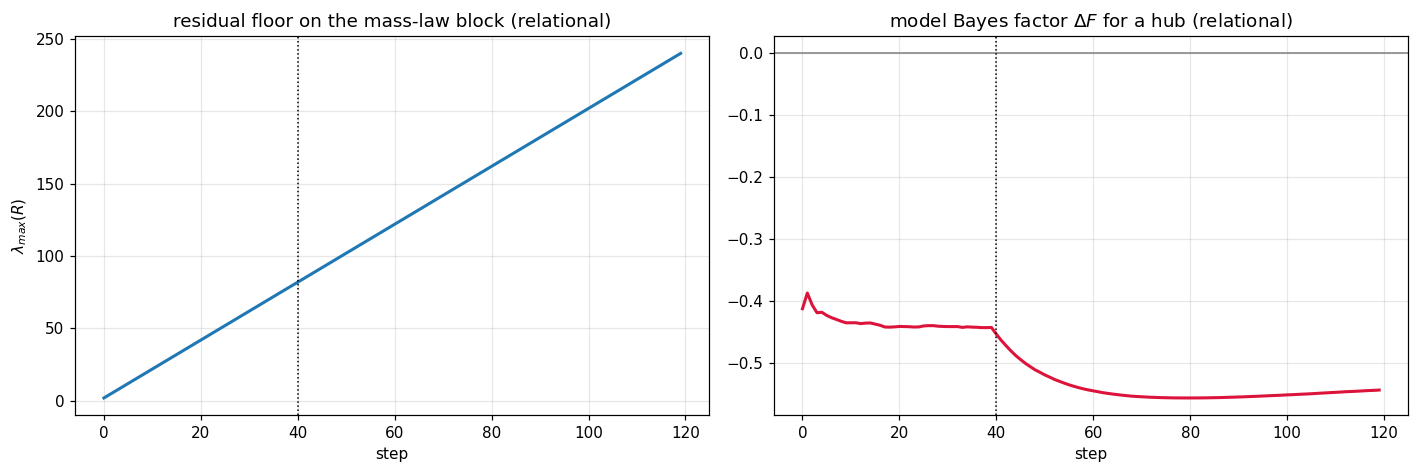

final relational hub delta_F = -0.54  (< 0: the precision already holds the coupling => DECLINE)
contrast B1: the BURIED (unconceived) residual gave delta_F >> 0 => WAKE.


In [10]:
mass = ph.DISAGREEMENT_NODES
floor_t, dF_t = [], []
for t in range(cfg.n_steps):
    Pim = jnp.asarray(np.asarray(Pi_t[t]).mean(0)); hm = jnp.asarray(np.asarray(h_t[t]).mean(0))
    netp = GaussianBeliefNet(Pi=Pim, h=hm, names=names)
    pr = action.propose_hub(netp, mass)
    sc = action.expansion_score(netp, prior, pr, 'mass_hub')
    floor_t.append(pr.strength); dF_t.append(sc.delta_F)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(floor_t, lw=2); a0.axvline(cfg.t_shift, color='k', ls=':', lw=1)
a0.set_title('residual floor on the mass-law block (relational)'); a0.set_xlabel('step'); a0.set_ylabel(r'$\lambda_{max}(R)$')
a1.plot(dF_t, lw=2, color='crimson'); a1.axhline(0, color='grey', lw=1); a1.axvline(cfg.t_shift, color='k', ls=':', lw=1)
a1.set_title(r'model Bayes factor $\Delta F$ for a hub (relational)'); a1.set_xlabel('step')
plt.tight_layout(); plt.savefig(RESULTS / 'B4_declined_when_learnable.png'); plt.show()
print(f'final relational hub delta_F = {dF_t[-1]:+.2f}  (< 0: the precision already holds the coupling => DECLINE)')
print('contrast B1: the BURIED (unconceived) residual gave delta_F >> 0 => WAKE.')

## B5 — When does expansion win? Sweep the anomaly strength

The trigger and the decision as the buried common cause `g` grows. `g = 0` (no hidden cause) →
flat floor, `ΔF = 0`, the agent **samples**. As `g` rises the floor rises, `ΔF` climbs, and the
agent **expands** past a threshold — exploration *derived*, not a posited bonus.

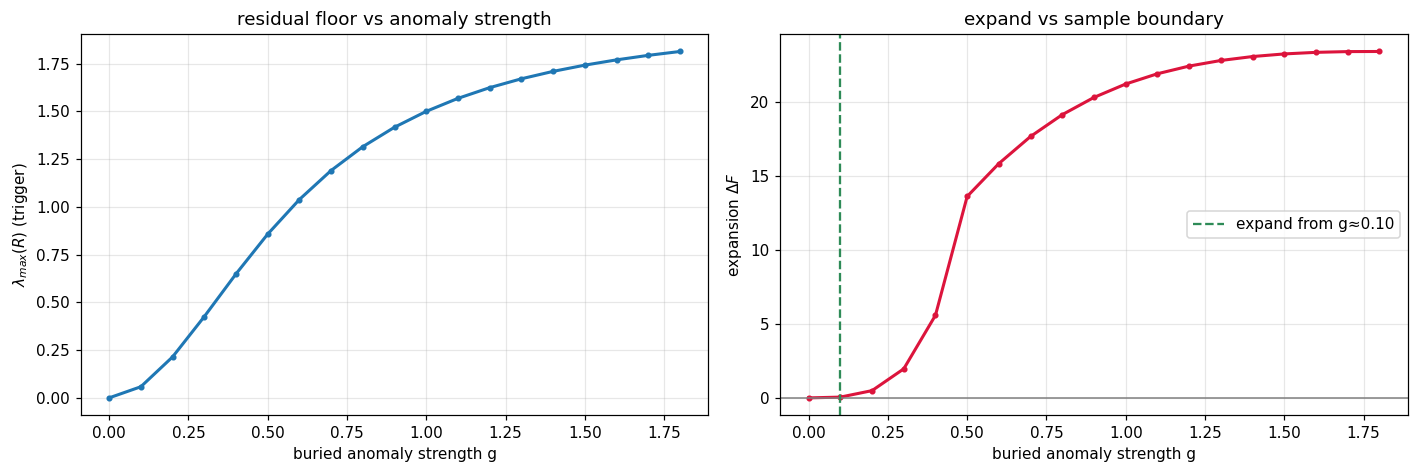

agent expands once g >= 0.1


In [11]:
gs = np.linspace(0.0, 1.8, 19)
floor_g, dF_g, acc_g = [], [], []
for g in gs:
    p = plant_common_cause(prior, bi, g=float(g))
    pr = action.propose_hub(p, buried); sc = action.expansion_score(p, prior, pr, 'buried_hub')
    floor_g.append(pr.strength); dF_g.append(sc.delta_F); acc_g.append(sc.accept)
acc_g = np.array(acc_g); thr = gs[acc_g][0] if acc_g.any() else None
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4))
a0.plot(gs, floor_g, lw=2, marker='o', ms=3); a0.set_xlabel('buried anomaly strength g'); a0.set_ylabel(r'$\lambda_{max}(R)$ (trigger)')
a0.set_title('residual floor vs anomaly strength')
a1.plot(gs, dF_g, lw=2, marker='o', ms=3, color='crimson'); a1.axhline(0, color='grey', lw=1)
if thr is not None: a1.axvline(thr, color='seagreen', ls='--', label=f'expand from g≈{thr:.2f}'); a1.legend()
a1.set_xlabel('buried anomaly strength g'); a1.set_ylabel(r'expansion $\Delta F$'); a1.set_title('expand vs sample boundary')
plt.tight_layout(); plt.savefig(RESULTS / 'B5_sweep_anomaly_strength.png'); plt.show()
print('agent expands once g >=', round(float(thr), 2) if thr is not None else 'never')

## B6 — The conviction veto = lock-in (the black hole holds)

The sharpest prediction. A high-conviction core can **value-reject an evidence-favoured wake**:
even with `ΔF + ΔG > 0`, a tilt `λ` whose conviction field opposes the anomaly's reading drives
the score negative — the agent *sees* the missing knob and refuses to build it. We sweep `(g, λ)`
and colour the chosen action: the escape region (expand) and the captured region (sample). The
boundary scales with the evidence — stronger anomalies need stronger conviction to suppress.

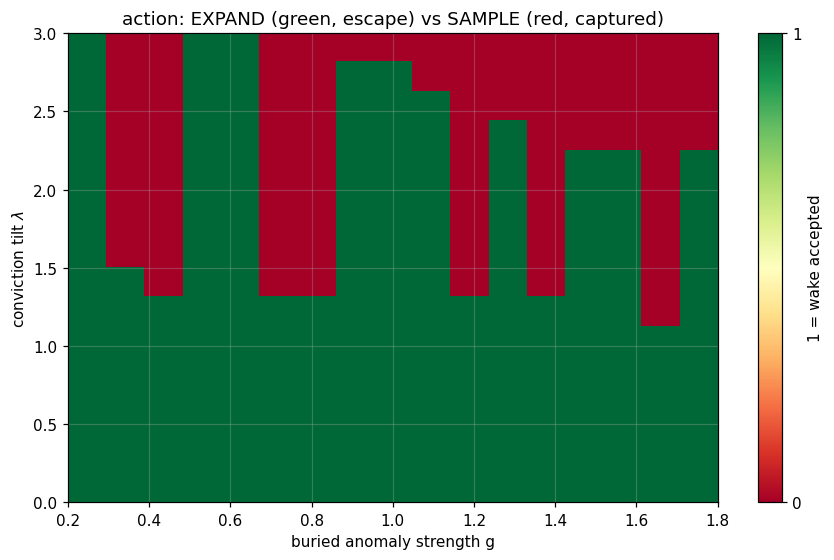

strong-anomaly (g=1.8) capture above some tilt: True <- conviction can lock in even an evidence-favoured expansion


In [12]:
u = jnp.zeros(len(names) + 1).at[jnp.asarray(bi)].set(-1.0)   # value opposes the anomaly direction
gs2 = np.linspace(0.2, 1.8, 17); tilts = np.linspace(0.0, 3.0, 16)
grid = np.zeros((len(tilts), len(gs2)))
for ig, g in enumerate(gs2):
    p = plant_common_cause(prior, bi, g=float(g)); pr = action.propose_hub(p, buried)
    for it, tl in enumerate(tilts):
        sc = action.expansion_score(p, prior, pr, 'buried_hub', u_full=u, tilt=float(tl))
        grid[it, ig] = 1.0 if sc.accept else 0.0
fig, ax = plt.subplots(figsize=(8.2, 5.2))
im = ax.imshow(grid, origin='lower', aspect='auto', cmap='RdYlGn',
               extent=[gs2[0], gs2[-1], tilts[0], tilts[-1]], vmin=0, vmax=1)
ax.set_xlabel('buried anomaly strength g'); ax.set_ylabel(r'conviction tilt $\lambda$')
ax.set_title('action: EXPAND (green, escape) vs SAMPLE (red, captured)')
fig.colorbar(im, ax=ax, ticks=[0, 1], label='1 = wake accepted')
plt.tight_layout(); plt.savefig(RESULTS / 'B6_conviction_veto_lockin.png'); plt.show()
captured = (grid[:, -1] == 0).any()
print('strong-anomaly (g=%.1f) capture above some tilt:' % gs2[-1], bool(captured),
      '<- conviction can lock in even an evidence-favoured expansion')

## Verdict

nb37 keeps nb36's five-figure structural showcase and adds the decision §3.2 names but never
writes: **structure revision as a scored action**, on `src/structural/action.py`.

* the **three moves on one ledger** — sample / reduce (closed-form ΔF) / expand (wake a dormant
  hub, the one real inversion) — with `select_action` arbitrating;
* the **inverse-Schur proposal** (Eq. 2 backwards): the residual floor's leading eigenpair is the
  trigger and the hub's coupling pattern;
* the **honest dual finding** — on the relational substrate `ΔF < 0` (structure learnable without
  expansion, normal science); expansion strictly wins only for the **unconceived** residual a
  paradigm holds conditionally independent (the black hole);
* the **anomaly-strength sweep** — exploration *derived*: the agent expands past a threshold in the
  floor, no posited bonus;
* the **conviction veto** — a high tilt value-rejects an evidence-favoured wake: the agent sees the
  missing knob and refuses to build it. Centrality (κ) sets how slowly the core moves; conviction
  (λ) sets whether it moves at all — the model's sharpest prediction, now an action the agent takes.